In [2]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt

In [11]:
# Define Parameters

# Policy Cost Means (in USD)
# The video uses a slightly different structure; this one focuses on clarity.
grocery_mean = 60_000_000
free_bus_mean = 711_507_000
rent_freeze_mean = 400_000_000
landlord_fee_mean = 1_500_000_000

# Standard Deviation (STD) to account for uncertainty

grocery_std = grocery_mean * 0.20
free_bus_std = free_bus_mean * 0.20
rent_freeze_std = rent_freeze_mean * 0.20
landlord_fee_std = landlord_fee_mean * 0.33 # Higher uncertainty

# Simulation Parameters
NUM_SIMULATIONS = 100_000 # Run 100,000 simulations for a good distribution
budget_threshold = 2_000_000_000 # $2 Billion threshold

print(f"Number of Simulations: {NUM_SIMULATIONS:,}")
print(f"Budget Threshold: ${budget_threshold:,.0f}")

Number of Simulations: 100,000
Budget Threshold: $2,000,000,000


In [10]:
# : Run the Monte Carlo Simulation

# Generate random costs for each policy across all simulations
# The size argument ensures we generate 100,000 random values for each
grocery_costs = np.random.normal(grocery_mean, grocery_std, NUM_SIMULATIONS)
free_bus_costs = np.random.normal(free_bus_mean, free_bus_std, NUM_SIMULATIONS)
rent_freeze_costs = np.random.normal(rent_freeze_mean, rent_freeze_std, NUM_SIMULATIONS)
landlord_fee_costs = np.random.normal(landlord_fee_mean, landlord_fee_std, NUM_SIMULATIONS)

# Calculating the Total Annual Cost for each simulation

total_annual_costs = (
    grocery_costs +
    free_bus_costs +
    rent_freeze_costs +
    landlord_fee_costs
)

# Optional: Ensure no negative costs, though highly unlikely with the chosen parameters
total_annual_costs[total_annual_costs < 0] = 0

print(f"Total simulations completed: {len(total_annual_costs):,}")

Total simulations completed: 100,000


In [9]:
# Calculating Key Metrics
mean_estimated_cost = np.mean(total_annual_costs)
max_estimated_cost = np.max(total_annual_costs)
min_estimated_cost = np.min(total_annual_costs)

# Calculating the probability of exceeding the budget threshold
# np.sum(total_annual_costs > budget_threshold) counts how many simulations exceeded the budget
exceed_count = np.sum(total_annual_costs > budget_threshold)
probability_of_exceeding = exceed_count / NUM_SIMULATIONS

print("\n--- Simulation Results ---")
print(f"Mean Estimated Total Cost: ${mean_estimated_cost:,.0f}")
print(f"Min Estimated Total Cost: ${min_estimated_cost:,.0f}")
print(f"Max Estimated Total Cost: ${max_estimated_cost:,.0f}")
print(f"Probability of Exceeding Budget (${budget_threshold:,.0f}): {probability_of_exceeding * 100:.2f}%")


--- Simulation Results ---
Mean Estimated Total Cost: $2,670,526,606
Min Estimated Total Cost: $297,361,161
Max Estimated Total Cost: $5,002,921,319
Probability of Exceeding Budget ($2,000,000,000): 90.00%


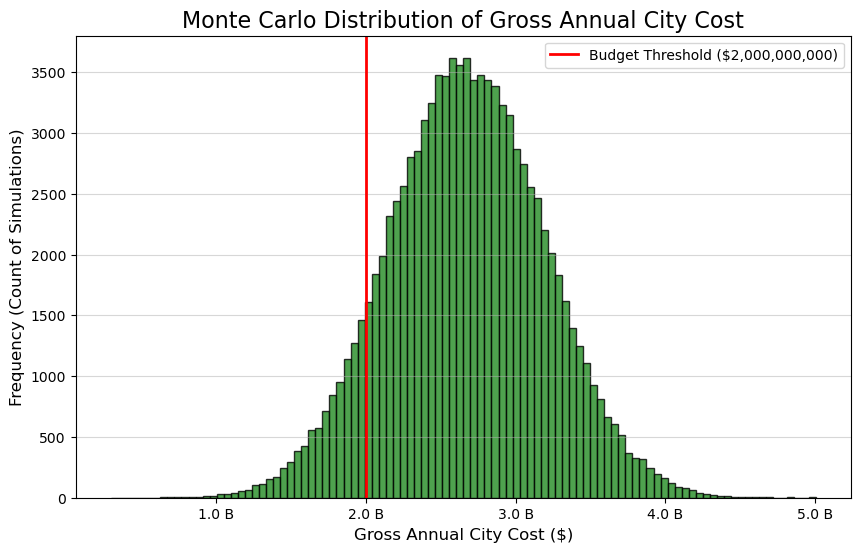

In [8]:
#  Visualizing the Distribution

plt.figure(figsize=(10, 6))

# Plot the histogram of the total annual costs
plt.hist(total_annual_costs, bins=100, color='forestgreen', alpha=0.8, edgecolor='black')

# Add the budget threshold line (Red line in the video)
plt.axvline(budget_threshold, color='red', linestyle='solid', linewidth=2, label=f'Budget Threshold (${budget_threshold:,.0f})')

# Add titles and labels
plt.title('Monte Carlo Distribution of Gross Annual City Cost', fontsize=16)
plt.xlabel('Gross Annual City Cost ($)', fontsize=12)
plt.ylabel('Frequency (Count of Simulations)', fontsize=12)
plt.ticklabel_format(style='plain', axis='x') # Prevent scientific notation on x-axis

# Format the x-axis to show in billions for better readability (Optional)

def millions_formatter(x, pos):
    'The two args are the value and tick position'
    return f'{x/1e9:,.1f} B'

from matplotlib.ticker import FuncFormatter
formatter = FuncFormatter(millions_formatter)
plt.gca().xaxis.set_major_formatter(formatter)


plt.legend()
plt.grid(axis='y', alpha=0.5)
plt.show()